In [1]:
# Core data science libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit‑learn modules
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import silhouette_score

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plot style and random seed
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
np.random.seed(42)

In [2]:
# Load Wine dataset
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df["target"] = wine_data.target

print("🍷 Wine Dataset - Summary")
print("="*60)
print(f"Shape: {wine_df.shape}")
print("\nFirst 5 rows:")
display(wine_df.head())
print("\nMissing values:")
print(wine_df.isnull().sum())
print("\nStatistical summary:")
display(wine_df.describe())
print("\nTarget distribution:")
print(wine_df['target'].value_counts())

🍷 Wine Dataset - Summary
Shape: (178, 14)

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Statistical summary:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



Target distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


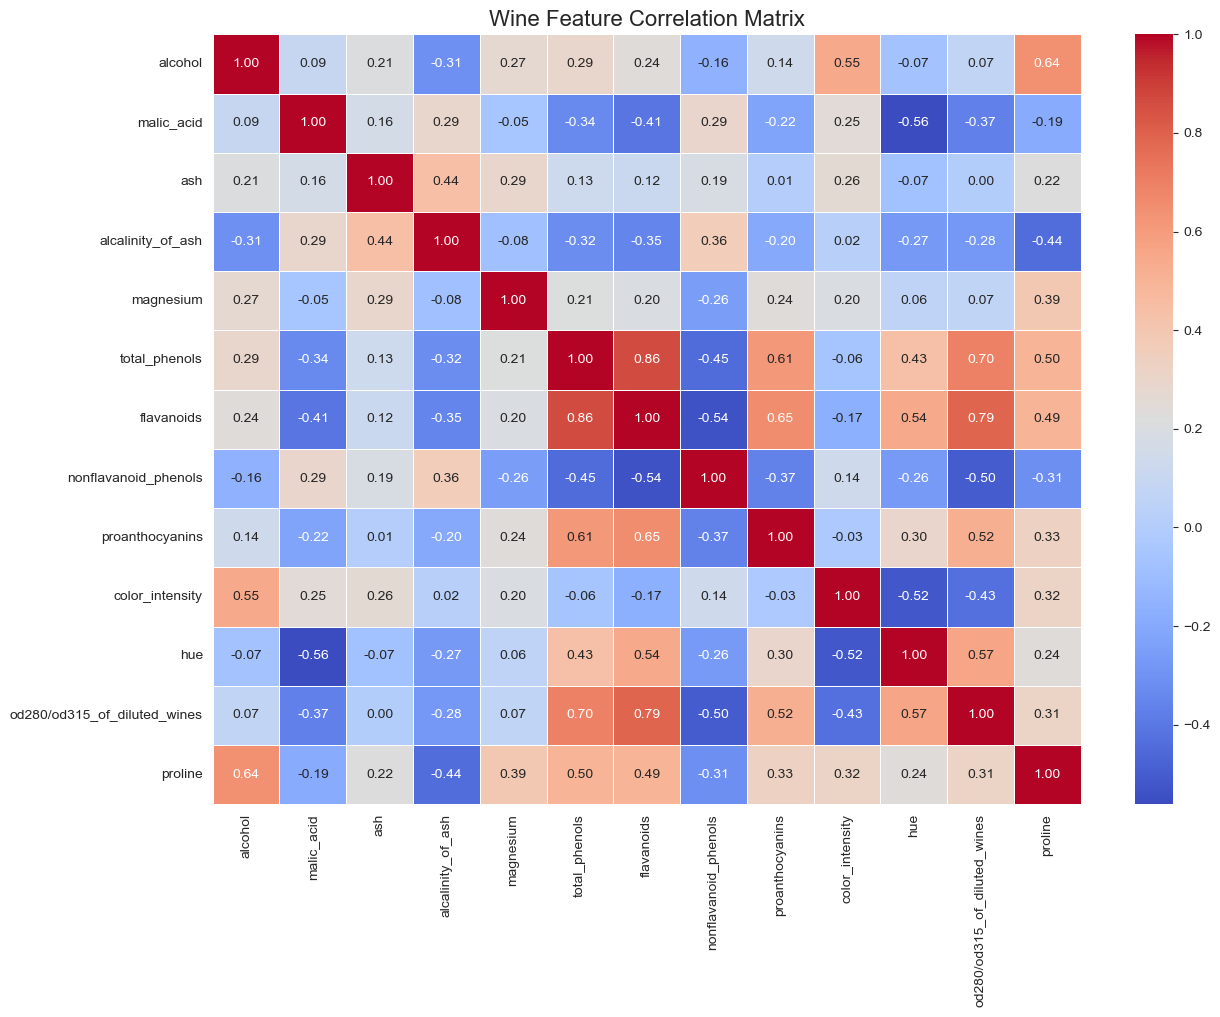

In [3]:
plt.figure(figsize=(14, 10))
sns.heatmap(wine_df.drop(columns='target').corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Wine Feature Correlation Matrix', fontsize=16)
plt.show()

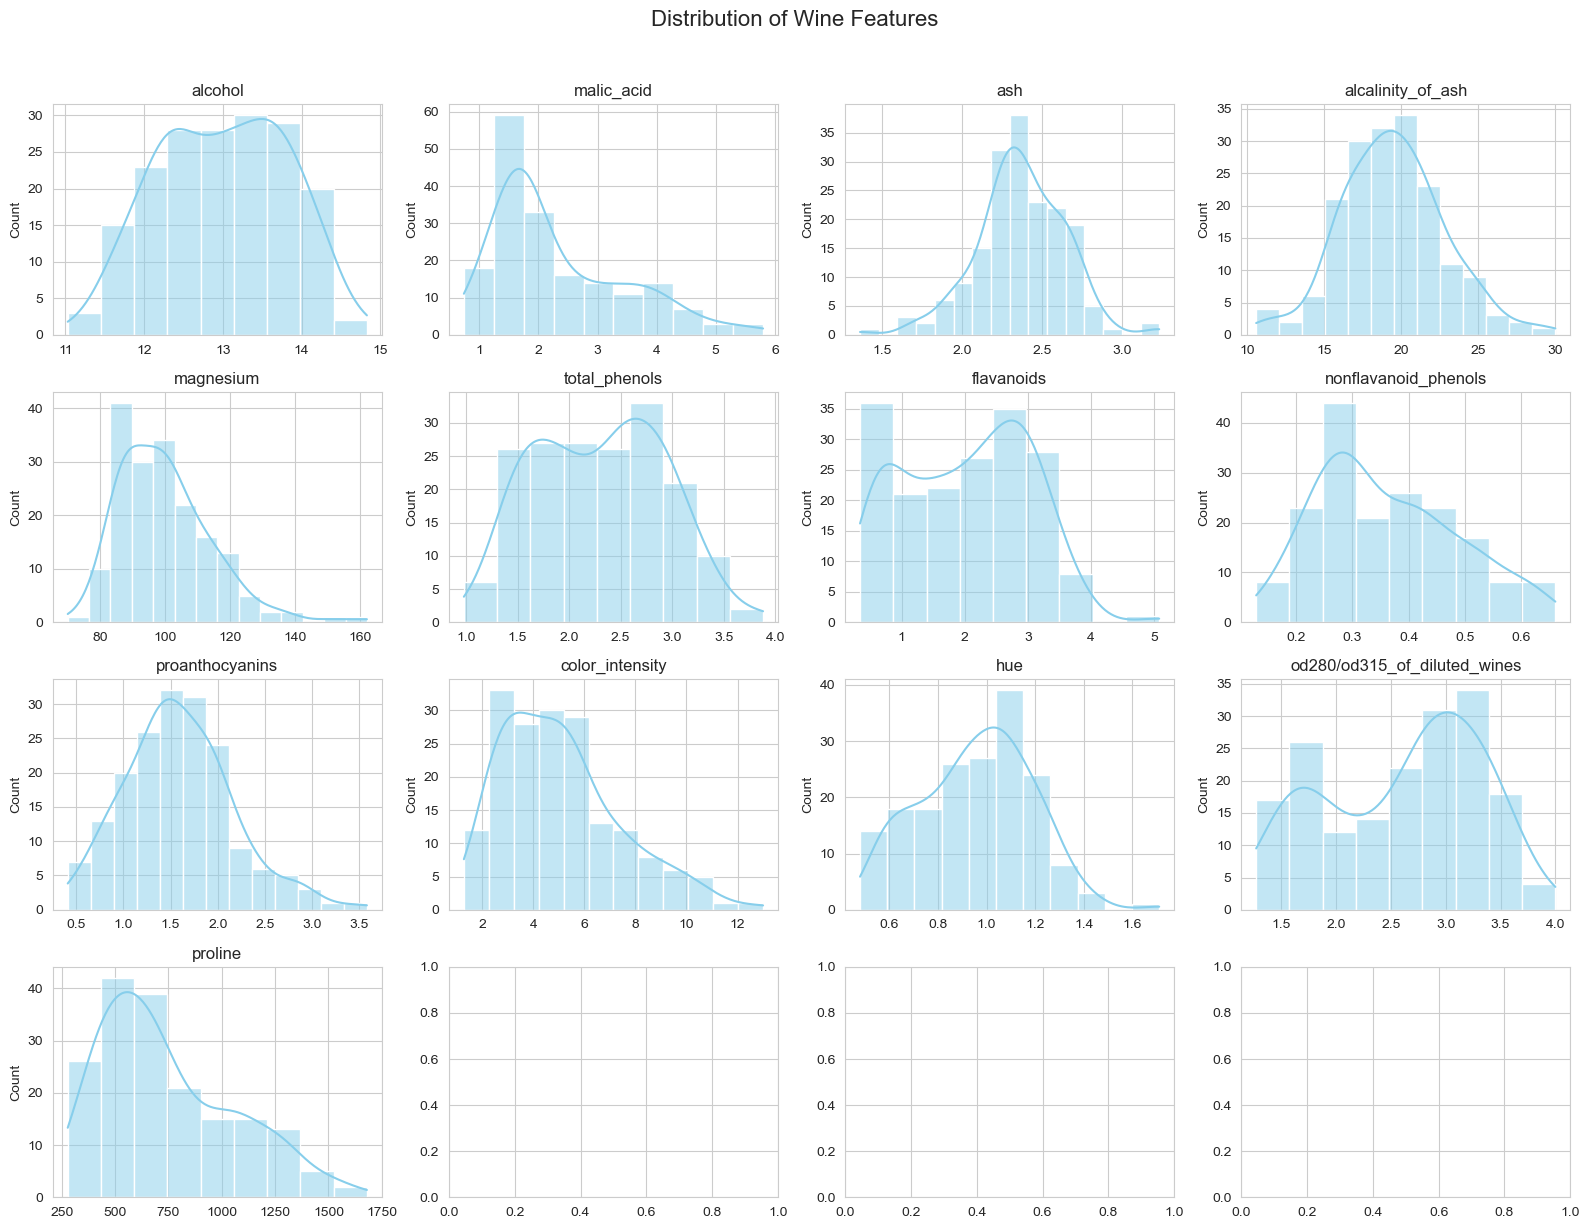

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(wine_df.drop(columns='target').columns):
    sns.histplot(wine_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Distribution of Wine Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Load Chickwts dataset from raw CSV URL
url_chick = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/chickwts.csv'
chickwts = pd.read_csv(url_chick, index_col=0)

print("🐣 Chickwts Dataset - Summary")
print("="*60)
print(f"Shape: {chickwts.shape}")
print("\nFirst 5 rows:")
display(chickwts.head())
print("\nMissing values:")
print(chickwts.isnull().sum())
print("\nStatistical summary:")
display(chickwts.describe())
print("\nFeed type counts:")
print(chickwts['feed'].value_counts())

🐣 Chickwts Dataset - Summary
Shape: (71, 2)

First 5 rows:


,weight,feed
rownames,,
1,179,horsebean
2,160,horsebean
3,136,horsebean
4,227,horsebean
5,217,horsebean



Missing values:
weight    0
feed      0
dtype: int64

Statistical summary:


,weight
count,71.000000
mean,261.309859
std,78.073700
min,108.000000
25%,204.500000
50%,258.000000
75%,323.500000
max,423.000000



Feed type counts:
feed
soybean      14
linseed      12
casein       12
sunflower    12
meatmeal     11
horsebean    10
Name: count, dtype: int64


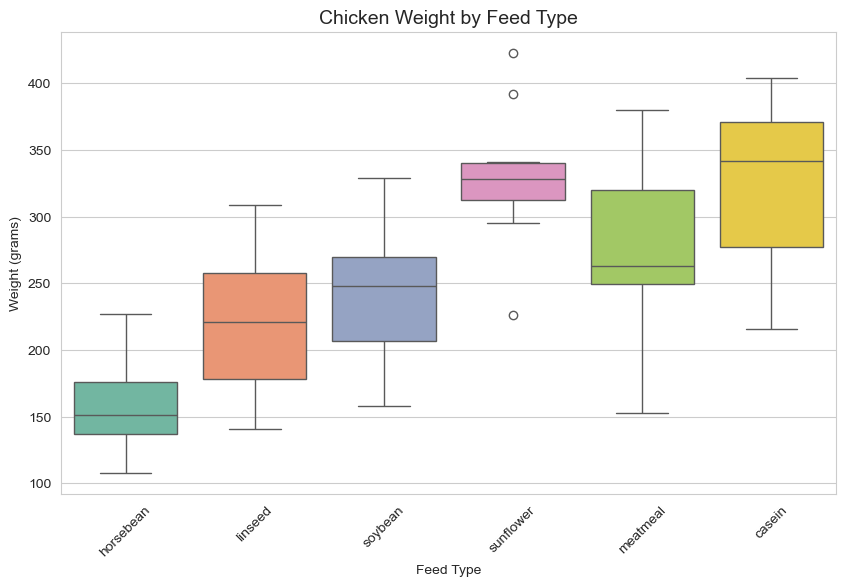

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='feed', y='weight', data=chickwts, palette='Set2')
plt.title('Chicken Weight by Feed Type', fontsize=14)
plt.xlabel('Feed Type')
plt.ylabel('Weight (grams)')
plt.xticks(rotation=45)
plt.show()

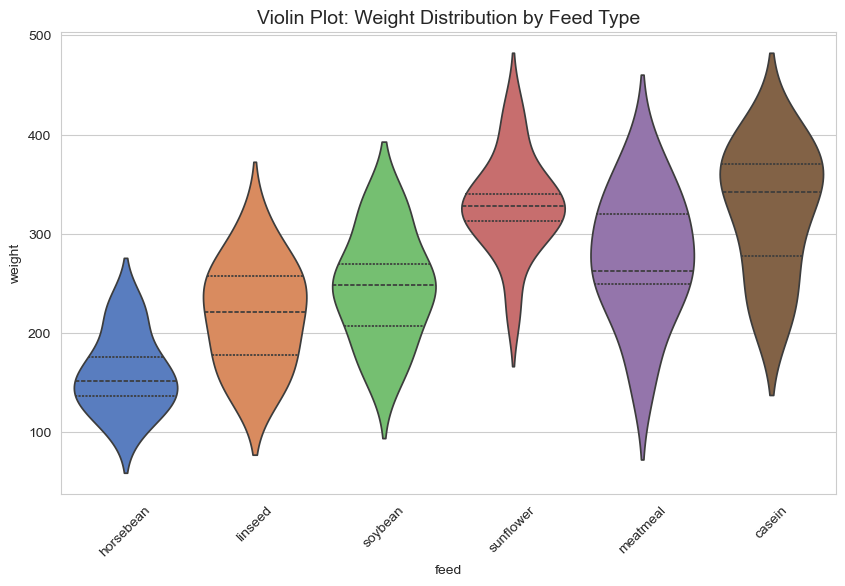

In [7]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='feed', y='weight', data=chickwts, palette='muted', inner='quartile')
plt.title('Violin Plot: Weight Distribution by Feed Type', fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [8]:
# Load USArrests dataset from raw CSV URL
url_arrests = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/USArrests.csv'
usarrests = pd.read_csv(url_arrests, index_col=0)

print("🚔 USArrests Dataset - Summary")
print("="*60)
print(f"Shape: {usarrests.shape}")
print("\nFirst 5 rows:")
display(usarrests.head())
print("\nMissing values:")
print(usarrests.isnull().sum())
print("\nStatistical summary:")
display(usarrests.describe())

🚔 USArrests Dataset - Summary
Shape: (50, 4)

First 5 rows:


,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6



Missing values:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

Statistical summary:


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


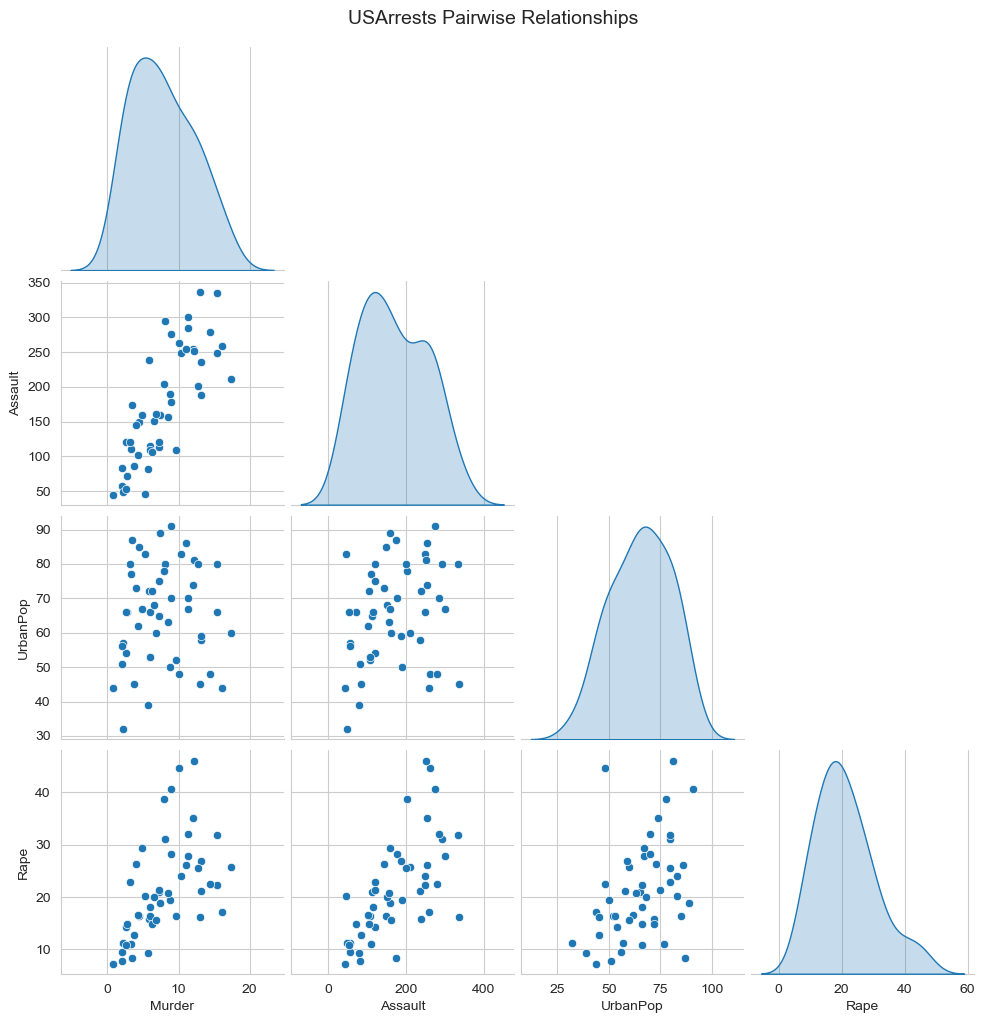

In [9]:
sns.pairplot(usarrests, diag_kind='kde', corner=True)
plt.suptitle('USArrests Pairwise Relationships', y=1.02, fontsize=14)
plt.show()

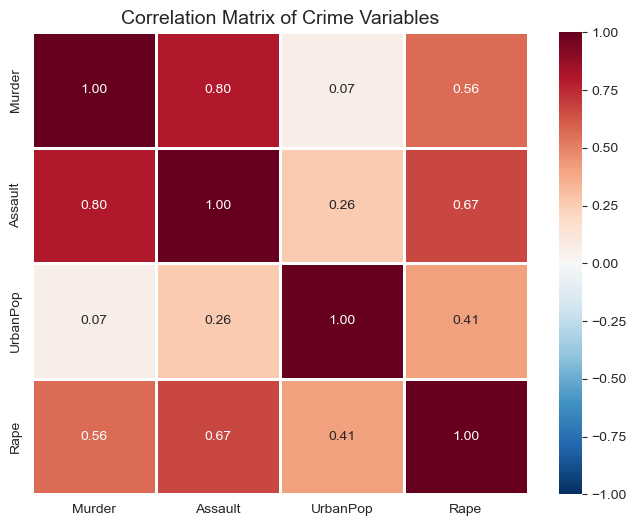

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(usarrests.corr(), annot=True, cmap='RdBu_r', fmt='.2f', linewidths=1, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Crime Variables', fontsize=14)
plt.show()

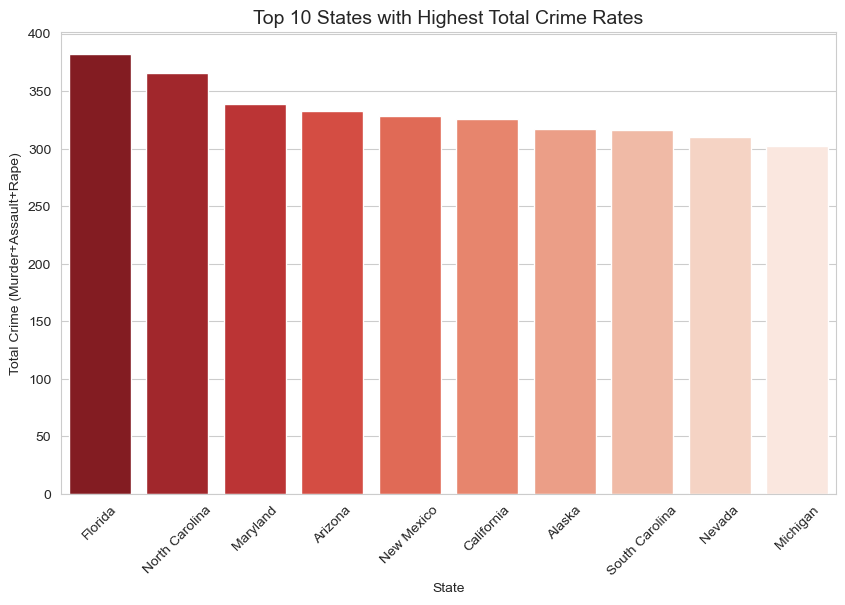

In [11]:
usarrests['total_crime'] = usarrests[['Murder', 'Assault', 'Rape']].sum(axis=1)
top_crime = usarrests.nlargest(10, 'total_crime')
plt.figure(figsize=(10, 6))
sns.barplot(x=top_crime.index, y=top_crime['total_crime'], palette='Reds_r')
plt.title('Top 10 States with Highest Total Crime Rates', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Crime (Murder+Assault+Rape)')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Separate features and target
X = wine_df.drop(columns=['target'])
y = wine_df['target']

# Split (stratify to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 142
Test samples: 36


In [13]:
# PCA with 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"PCA components (95% variance): {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.cumsum(pca.explained_variance_ratio_)}")

Original features: 13
PCA components (95% variance): 10
Explained variance ratio: [0.35792104 0.19270671 0.11019835 0.07272276 0.06721919 0.05131943
 0.04377423 0.02500853 0.0227943  0.01877102]
Cumulative explained variance: [0.35792104 0.55062776 0.66082611 0.73354887 0.80076806 0.85208748
 0.89586171 0.92087024 0.94366454 0.96243556]


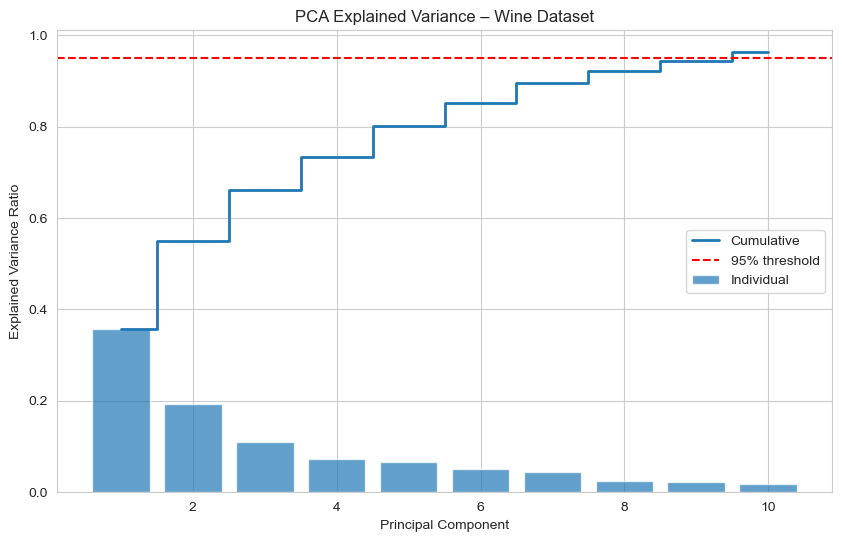

In [14]:
plt.figure(figsize=(10,6))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), 
         np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative', lw=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance – Wine Dataset')
plt.legend()
plt.show()

In [15]:
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)

print(f"🏆 Best parameters: {grid_search.best_params_}")
print(f"🏆 Best cross‑validation accuracy: {grid_search.best_score_:.4f}")

🏆 Best parameters: {'metric': 'euclidean', 'n_neighbors': 18, 'p': 1}
🏆 Best cross‑validation accuracy: 0.9791


In [16]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_pca)

print(f"✅ Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine_data.target_names))

✅ Test Accuracy: 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



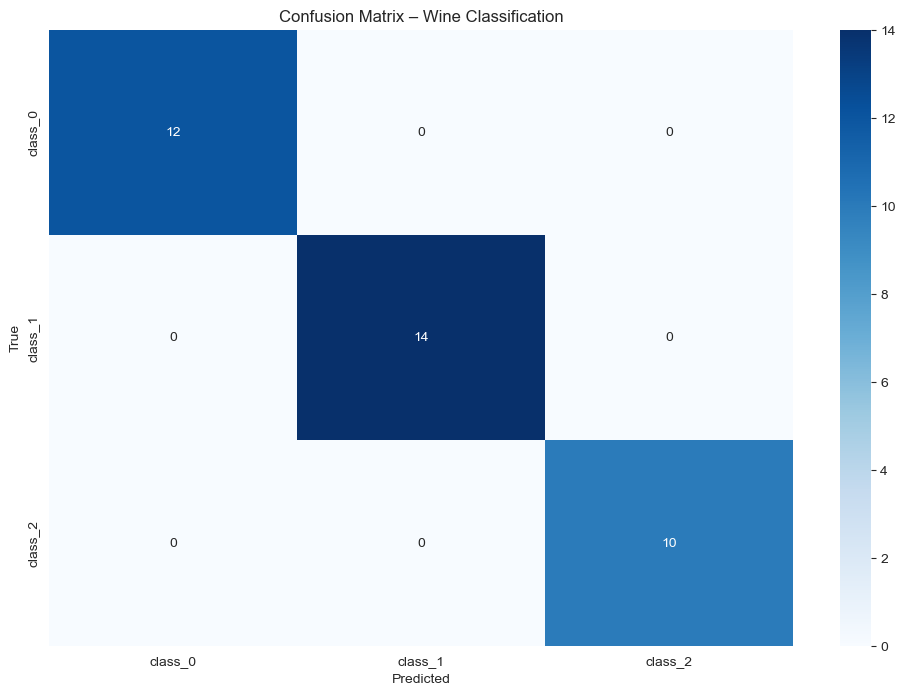

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine_data.target_names, yticklabels=wine_data.target_names)
plt.title('Confusion Matrix – Wine Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

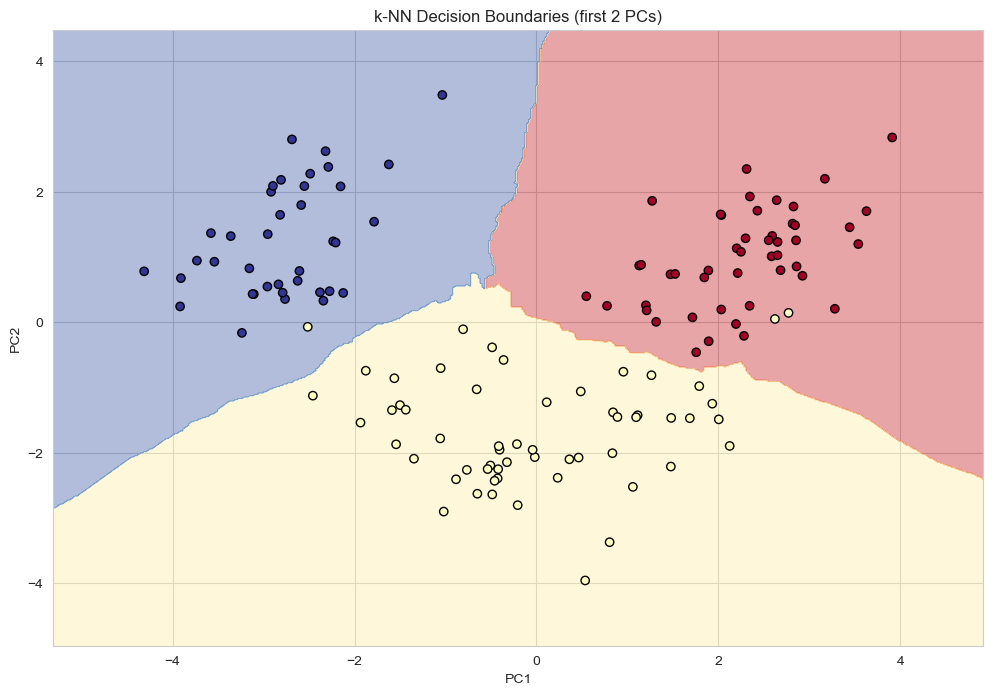

In [18]:
# Reduce to 2D for visualisation
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
X_test_2d = pca_2d.transform(X_test_scaled)

# Train a k-NN with best parameters on 2D data
knn_2d = KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors'],
                              metric=grid_search.best_params_['metric'])
knn_2d.fit(X_train_2d, y_train)

# Mesh plot
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title('k-NN Decision Boundaries (first 2 PCs)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [19]:
# Group by feed and compute statistics
feed_stats = chickwts.groupby('feed')['weight'].agg([
    'mean', 'std', 'min', 'max', 'median',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    'skew', 'kurt'   # 'kurt' is the correct pandas method for kurtosis
]).reset_index()
feed_stats.columns = ['feed', 'mean', 'std', 'min', 'max', 'median', 'q25', 'q75', 'skew', 'kurtosis']
feed_stats.set_index('feed', inplace=True)

print("Feature matrix per feed type:")
display(feed_stats)

AttributeError: 'SeriesGroupBy' object has no attribute 'kurt'

In [ ]:
scaler_feed = StandardScaler()
feed_scaled = scaler_feed.fit_transform(feed_stats)
feed_scaled_df = pd.DataFrame(feed_scaled, index=feed_stats.index, columns=feed_stats.columns)
print("Standardised features:")
display(feed_scaled_df)

In [ ]:
# PCA to 1 component
pca_feed = PCA(n_components=1)
feed_pca = pca_feed.fit_transform(feed_scaled)
feed_pca_df = pd.DataFrame(feed_pca, index=feed_stats.index, columns=['PC1'])

print(f"Explained variance ratio (1 PC): {pca_feed.explained_variance_ratio_[0]:.3f}")
print("PC1 scores:")
display(feed_pca_df)

# Cosine similarity on full standardised features (most informative)
cos_sim_full = cosine_similarity(feed_scaled)
cos_sim_full_df = pd.DataFrame(cos_sim_full, index=feed_stats.index, columns=feed_stats.index)

plt.figure(figsize=(8,6))
sns.heatmap(cos_sim_full_df, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Cosine Similarity Between Feed Types (Full Features)')
plt.show()

In [ ]:
def recommend_feeds(feed_type, similarity_df, top_n=3):
    if feed_type not in similarity_df.index:
        return f"❌ {feed_type} not found."
    sim_series = similarity_df.loc[feed_type].drop(feed_type)
    return sim_series.sort_values(ascending=False).head(top_n)

# Example recommendations
print("🔍 Top 3 feeds most similar to 'casein':")
display(recommend_feeds('casein', cos_sim_full_df))

print("\n🔍 Top 3 feeds most similar to 'horsebean':")
display(recommend_feeds('horsebean', cos_sim_full_df))

In [ ]:
# Standardise (exclude total_crime if we added it)
arrests_scaled = scaler_arrests.fit_transform(usarrests.iloc[:, :4])
arrests_scaled_df = pd.DataFrame(arrests_scaled, columns=usarrests.columns[:4], index=usarrests.index)

# Determine top 3 features via PCA loadings
pca_select = PCA(n_components=2)
pca_select.fit(arrests_scaled)
loadings = pd.DataFrame(pca_select.components_.T, columns=['PC1', 'PC2'], index=usarrests.columns[:4])
loadings['abs_sum'] = loadings.abs().sum(axis=1)
top3 = loadings.nlargest(3, 'abs_sum').index.tolist()
print(f"✅ Top 3 features selected: {top3}")

# Use these features for clustering
X_cluster = arrests_scaled_df[top3]

In [ ]:
# Elbow method
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

# BIC for GMM
bics = []
for n in range(1, 11):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_cluster)
    bics.append(gmm.bic(X_cluster))

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for K‑Means')
ax1.axvline(x=4, color='r', linestyle='--', label='Suggested k=4')
ax1.legend()

ax2.plot(range(1, 11), bics, 'ro-')
ax2.set_xlabel('Number of components')
ax2.set_ylabel('BIC')
ax2.set_title('BIC for GMM')
ax2.axvline(x=4, color='b', linestyle='--', label='Suggested n=4')
ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
# PCA for visualisation (on full standardised data)
pca_viz = PCA(n_components=2)
arrests_pca = pca_viz.fit_transform(arrests_scaled)
arrests_pca_df = pd.DataFrame(arrests_pca, columns=['PC1', 'PC2'], index=usarrests.index)

# Fit models
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_cluster)

# Add cluster labels to dataframe
usarrests['KMeans_Cluster'] = kmeans_labels
usarrests['GMM_Cluster'] = gmm_labels

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=arrests_pca_df['PC1'], y=arrests_pca_df['PC2'],
                hue=kmeans_labels, palette='Set1', s=100, ax=axes[0])
axes[0].set_title('K‑Means Clusters (k=4)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

sns.scatterplot(x=arrests_pca_df['PC1'], y=arrests_pca_df['PC2'],
                hue=gmm_labels, palette='Set2', s=100, ax=axes[1])
axes[1].set_title('GMM Clusters (k=4)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [ ]:
# Silhouette scores
sil_k = silhouette_score(X_cluster, kmeans_labels)
sil_g = silhouette_score(X_cluster, gmm_labels)
print(f"📊 Silhouette Score – K‑Means: {sil_k:.3f}")
print(f"📊 Silhouette Score – GMM: {sil_g:.3f}")

# Cluster profiles
cluster_profiles = usarrests.groupby('KMeans_Cluster')[['Murder', 'Assault', 'Rape', 'UrbanPop']].mean()
print("\n📋 Cluster profiles (K‑Means):")
display(cluster_profiles)